Описание датасета:

rank: Position of the YouTube channel based on the number of subscribers ## позиция ютуб канала, основанная на числе подписчиков

Youtuber: Name of the YouTube channel

subscribers: Number of subscribers to the channel

video views: Total views across all videos on the channel ## Общее количество просмотров всех видео на канале

category: Category or niche of the channel

Title: Title of the YouTube channel

uploads: Total number of videos uploaded on the channel ## Общее количество видео, загруженных на канал

Country: Country where the YouTube channel originates

Abbreviation: Abbreviation of the country ## Сокращенное название страны

channel_type: Type of the YouTube channel (e.g., individual, brand)

video_views_rank: Ranking of the channel based on total video views

country_rank: Ranking of the channel based on the number of subscribers within its country

channel_type_rank: Ranking of the channel based on its type (individual or brand)

video_views_for_the_last_30_days: Total video views in the last 30 days

lowest_monthly_earnings: Lowest estimated monthly earnings from the channel ## Самый низкий предполагаемый доход от канала

highest_monthly_earnings: Highest estimated monthly earnings from the channel

lowest_yearly_earnings: Lowest estimated yearly earnings from the channel

highest_yearly_earnings: Highest estimated yearly earnings from the channel

subscribers_for_last_30_days: Number of new subscribers gained in the last 30 days

created_year: Year when the YouTube channel was created

created_month: Month when the YouTube channel was created

created_date: Exact date of the YouTube channel’s creation

Gross tertiary education enrollment (%): Percentage of the population enrolled in tertiary education in the country ## Процент населения, обучающегося в высших учебных заведениях страны

Population: Total population of the country

Unemployment rate: Unemployment rate in the country ## Уровень безработицы в стране

Urban_population: Percentage of the population living in urban areas ## Процент населения, проживающий в городе

Latitude: Latitude coordinate of the country’s location

Longitude: Longitude coordinate of the country’s location

# Задание 1. EDA
Проведите разведывательный анализ данных (EDA).

1. Задайте не менее 6 вопросов к данным и постарайтесь ответить на них, используя визуализацию.
2. Изобразите матрицу корреляций для нахождения взаимосвязей.

In [32]:
import pandas as pd
import scipy.stats as st
from scipy.stats import ttest_ind
from scipy.stats import f_oneway, shapiro
import seaborn as sns

import matplotlib.pyplot as plt
import chardet
 
with open('/Users/sofagusina/Desktop/программирование/machine_learning/статистика/statictics/итоговая работа/Global YouTube Statistics 2.csv', 'rb') as f:
    result = chardet.detect(f.read())

import re

In [126]:
data_youtube = pd.read_csv('/Users/sofagusina/Desktop/программирование/machine_learning/статистика/statictics/итоговая работа/Global YouTube Statistics 2.csv',encoding=result['encoding'])
data_youtube.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [127]:
data_youtube.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    object 
 8   Abbreviation                             873 non-null    object 
 9   channel_type                             965 non-null    object 
 10  video_views_rank                         994 non-n

В связи с тем, что пропусков в данных  достаточно много, заменим их другими значениями. Кроме столбцов category, country, abbrevation, latitude,  longtitude, Gross tertiary education enrollment, Population,Unemployment rate, Urban_population так как замена этих столбцов другими данными может исказить характеристики

In [118]:
# """Заменим пропуски в столбце channel_type_rank в зависимости от того, множественное число в названии канала"""
# def fill_channel_type(row):
#     if pd.isnull(row['channel_type_rank']):
#         if re.search(r's$', row['Youtuber']):
#             return 'brand'
#         else:
#             return 'individual'                             
#     else:
#         return row['channel_type_rank']


In [130]:
data_youtube['channel_type'] = data_youtube['channel_type'].fillna(data_youtube.groupby('category')['channel_type'].transform(lambda x: x.mode()[0]))
data_youtube['video_views_rank'] = data_youtube['video_views_rank'].fillna(data_youtube['video_views_rank'].median())

data_youtube['channel_type_rank'] = data_youtube['channel_type_rank'].fillna(data_youtube.groupby('channel_type')['channel_type_rank'].transform('median'))

data_youtube['country_rank'] = data_youtube['country_rank'].fillna(data_youtube['country_rank'].median())

data_youtube['video_views_for_the_last_30_days'] = data_youtube['video_views_for_the_last_30_days'].fillna(data_youtube.groupby('channel_type')['video_views_for_the_last_30_days'].transform('median'))


In [131]:
data_youtube.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    object 
 8   Abbreviation                             873 non-null    object 
 9   channel_type                             992 non-null    object 
 10  video_views_rank                         995 non-n

Вопросы к данным:
1) Правда ли, что ютуберы с США имеют максимальный ожидаемый доход с Ютуба больше, чем ютуберы из Индии? 

Сравниваться будут удельные доходы, так как население Индии во много раз превышает население США

Считаем, что доход распределен на всех жителей страны

Text(0.5, 0, 'Название страны')

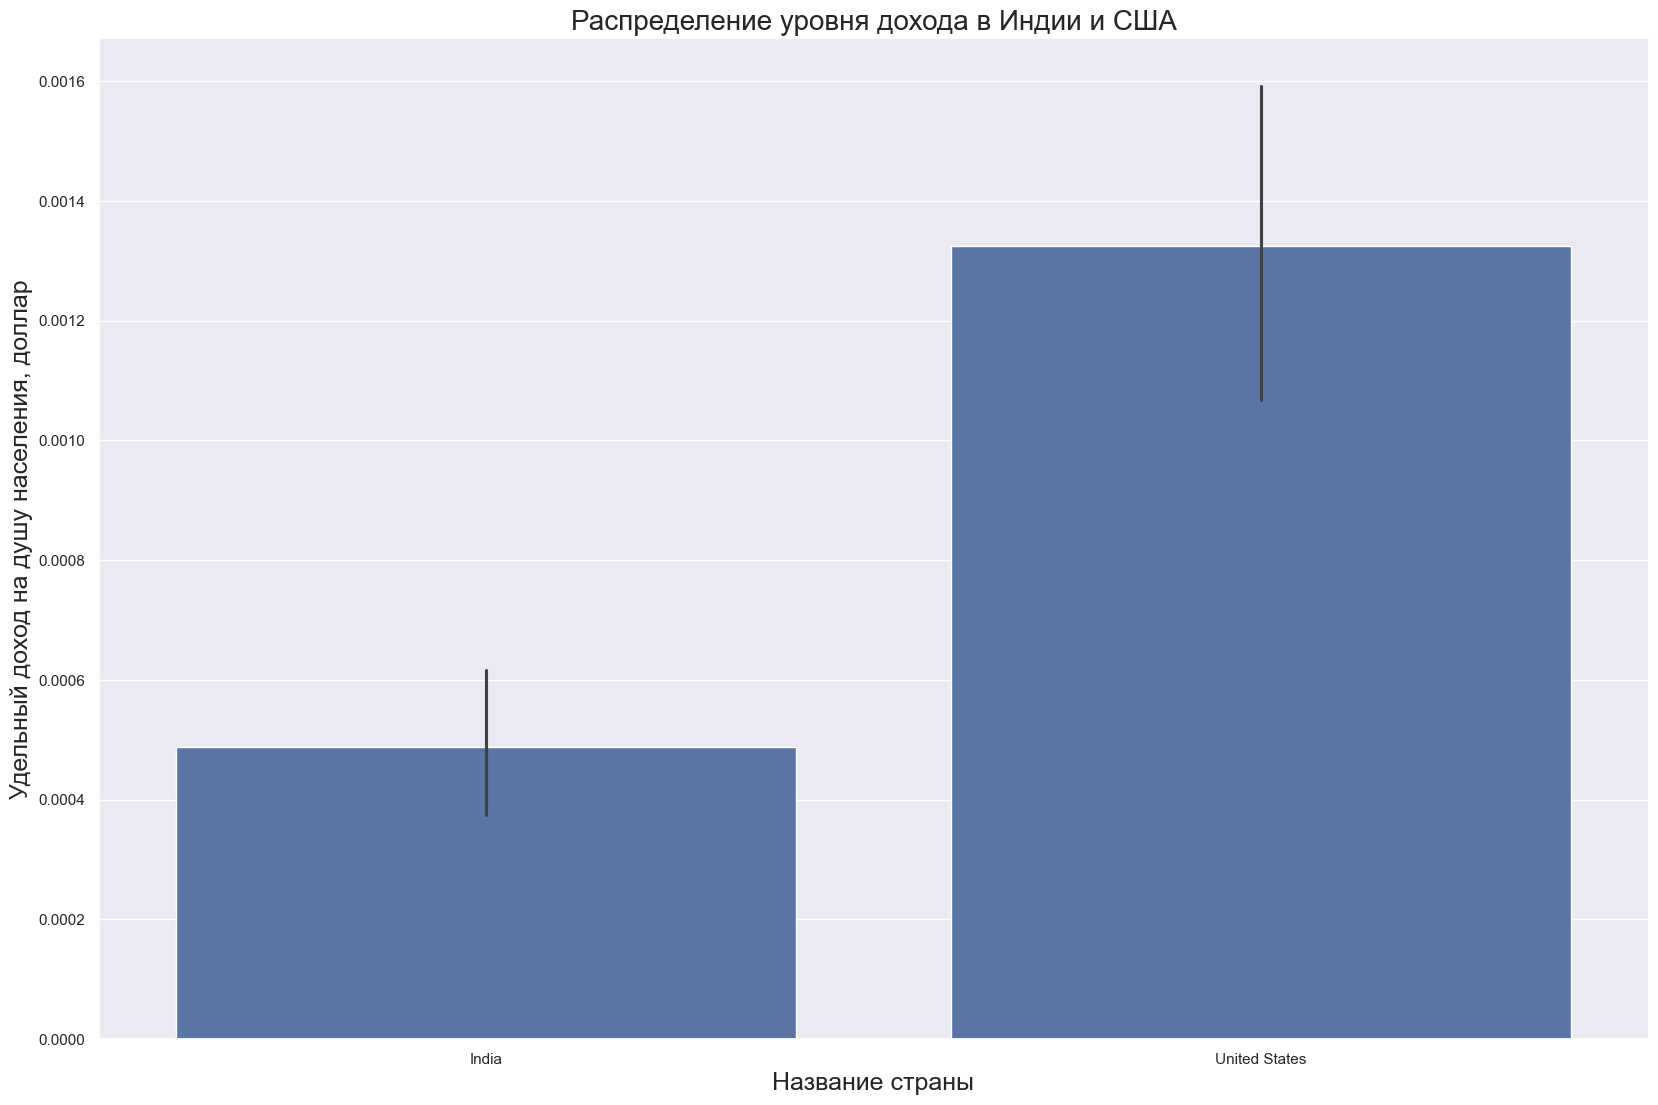

In [181]:
data_youtube['unit_earnings'] = data_youtube['lowest_yearly_earnings']/data_youtube['Population']

sns.barplot(data = data_youtube[(data_youtube['Country'] == 'India') | (data_youtube['Country'] == 'United States')], x = 'Country', y = 'unit_earnings')
plt.title('Распределение уровня дохода в Индии и США',fontsize = 20)
plt.ylabel('Удельный доход на душу населения, доллар',fontsize = 18)
plt.xlabel('Название страны',fontsize = 18)

Ответ: да, удельный доход в Америке больше, чем в Индии. Безусловно, что допущение о том, что каждый житель страны имеет доход с ютуба, абсолютно некорретно, но в рамках учебной задачи его можно принять.

2) Правда ли, что при количество просмотров за последние 30 дней и доход с канала за месяц прямо коррелируют между собой?


Text(0.5, 1.0, 'Зависимость максимально ожидаемого дохода от количества просмотров за месяц')

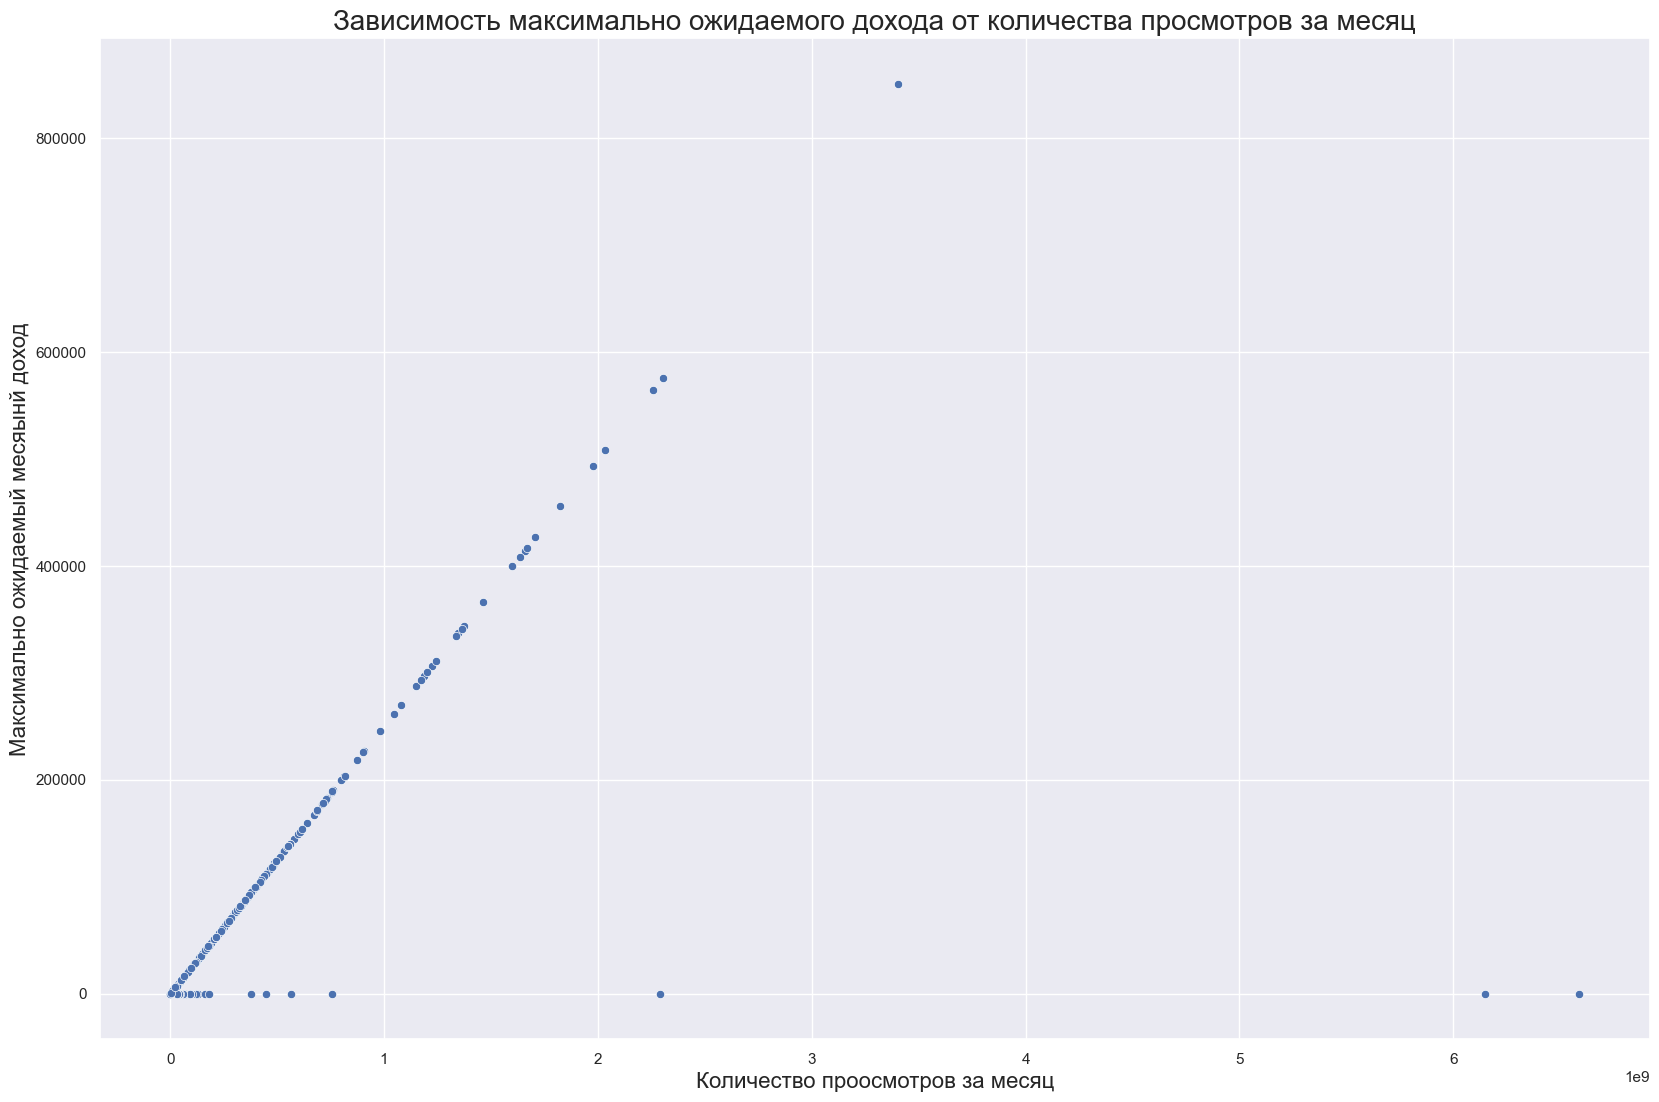

In [177]:
sns.scatterplot(data=data_youtube,x = 'video_views_for_the_last_30_days', y='lowest_monthly_earnings')
plt.xlabel('Количество проосмотров за месяц',fontsize = 16)
plt.ylabel('Максимально ожидаемый месяынй доход',fontsize = 16)
plt.title('Зависимость максимально ожидаемого дохода от количества просмотров за месяц',fontsize = 20)


Ответ: да, данные демонстрируют линейную зависимость между месячным доходом и количеством просмотров. В данных есть выбросы, но общую картину они не портят

3) Правда ли, что более молодые каналы имеют меньшее количество просмотров за месяц?

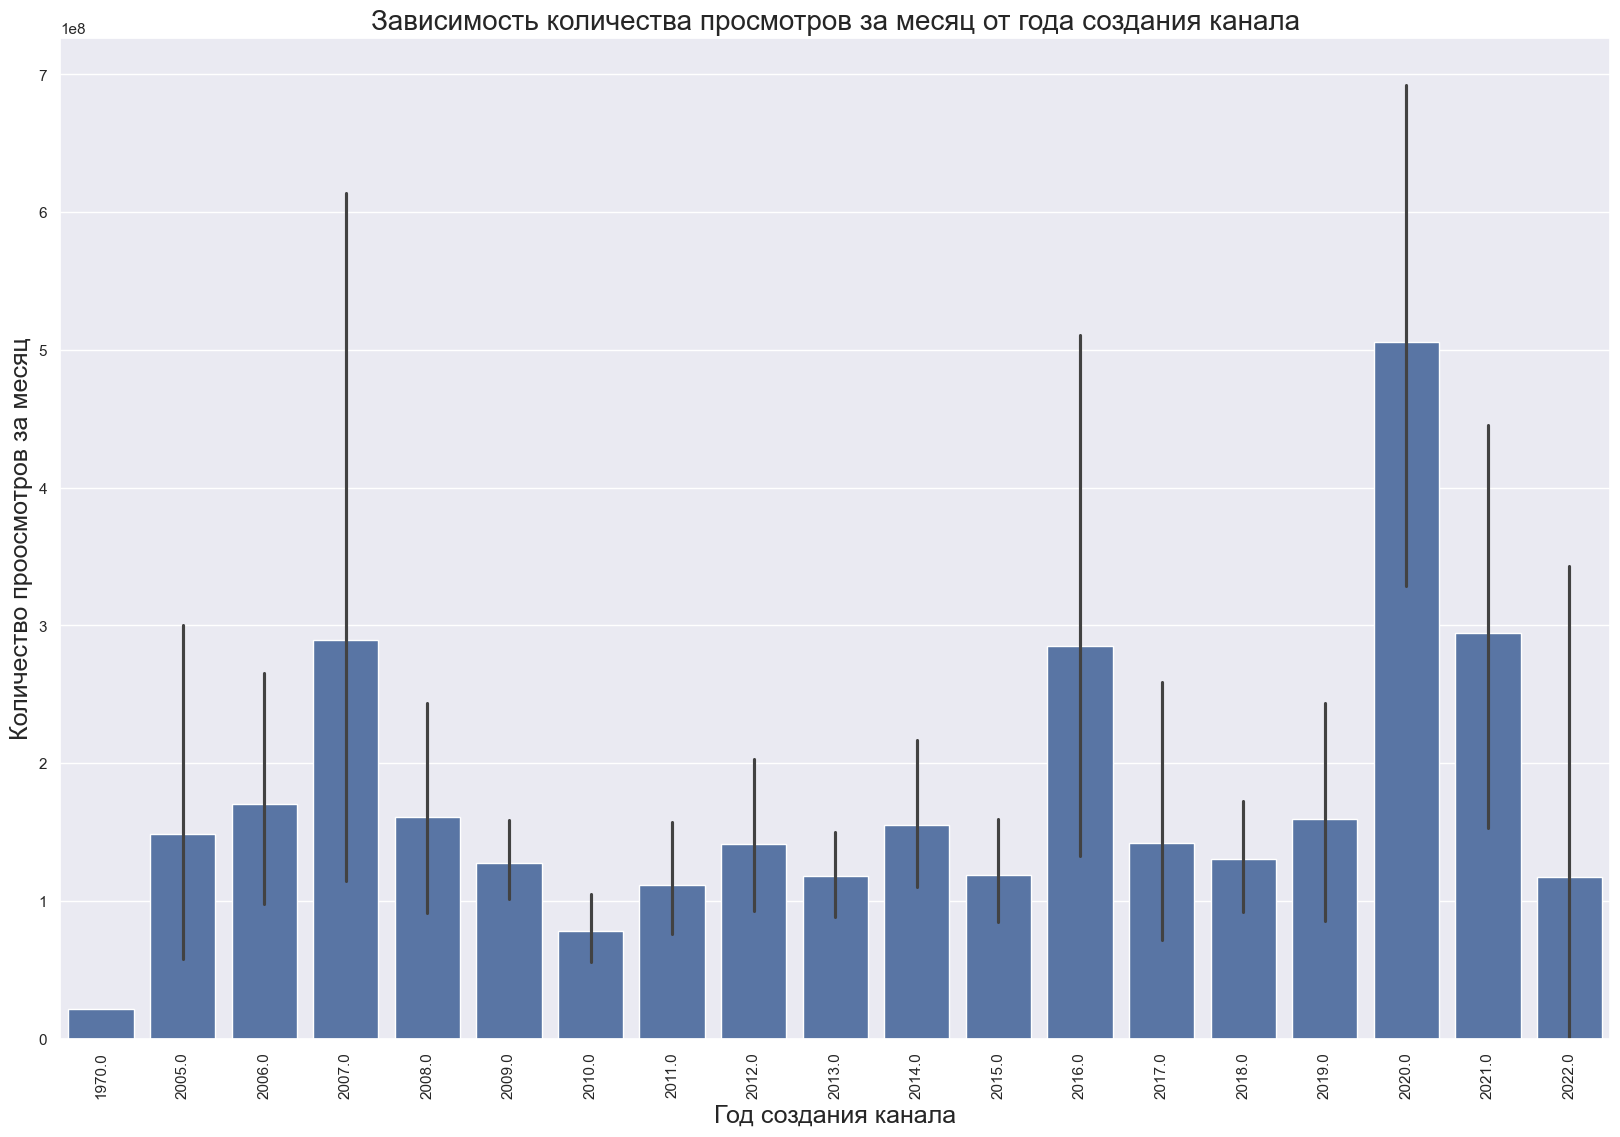

In [178]:
sns.barplot(data=data_youtube, x='created_year', y='video_views_for_the_last_30_days')
plt.ylabel('Количество проосмотров за месяц',fontsize = 18)
plt.xlabel('Год создания канала',fontsize = 18)
plt.xticks(rotation=90)
plt.title('Зависимость количества просмотров за месяц от года создания канала',fontsize = 20)
plt.show()


Ответ: нет, не правда. 

Правда ли, что в странах ближнего востока людей с высшим образованием меньше, чем в странах Европы?

In [81]:
array_country = data_youtube['Country'].unique()
array_country

array(['India', 'United States', nan, 'Japan', 'Russia', 'South Korea',
       'United Kingdom', 'Canada', 'Brazil', 'Argentina', 'Chile', 'Cuba',
       'El Salvador', 'Pakistan', 'Philippines', 'Thailand', 'Colombia',
       'Barbados', 'Mexico', 'United Arab Emirates', 'Spain',
       'Saudi Arabia', 'Indonesia', 'Turkey', 'Venezuela', 'Kuwait',
       'Jordan', 'Netherlands', 'Singapore', 'Australia', 'Italy',
       'Germany', 'France', 'Sweden', 'Afghanistan', 'Ukraine', 'Latvia',
       'Switzerland', 'Vietnam', 'Malaysia', 'China', 'Iraq', 'Egypt',
       'Andorra', 'Ecuador', 'Morocco', 'Peru', 'Bangladesh', 'Finland',
       'Samoa'], dtype=object)

In [109]:
country_europe = [ 
"Austria", "Albania", "Andorra", "Belarus", "Belgium", "Bosnia and Herzegovina", 
"Bulgaria", "Vatican", "Great Britain", "Hungary", "Germany", "Greece", 
"Denmark", "Ireland", "Iceland", "Spain", "Italy", "Cyprus", "Latvia", 
"Lithuania", "Liechtenstein", "Luxembourg", "Malta", "Moldova", "Monaco", 
"Netherlands", "North Macedonia", "Norway", "Poland", "Portugal", 
"Romania", "Russia", "San Marino", "Serbia", "Slovakia", "Slovenia", 
"Ukraine", "Finland", "France", "Croatia", "Montenegro", "Czech Republic",
"Switzerland", "Sweden", "Estonia", "Kosovo"
]
country_africa = ["Algeria", "Bahrain", "Jordan", "Kuwait", "Lebanon",
"Morocco", "Oman", "Qatar", "Saudi Arabia", "United Arab Emirates"]



array_country_europe = []
array_country_africa = []

for country in array_country:
        if country in country_europe:
            array_country_europe.append(country)
        elif country in country_africa:
            array_country_africa.append(country)

print(array_country_africa, array_country_europe)

mean_education_europe = data_youtube[data_youtube['Country'].isin(array_country_europe)]['Gross tertiary education enrollment (%)'].mean()
mean_education_africa = data_youtube[data_youtube['Country'].isin(array_country_africa)]['Gross tertiary education enrollment (%)'].mean()
print(f'Среднее значение числа людей, имеющих высшее образование: в странах Европы {mean_education_europe:.2f}, в странах Африки {mean_education_africa:.2f} в процентах')



['United Arab Emirates', 'Saudi Arabia', 'Kuwait', 'Jordan', 'Morocco'] ['Russia', 'Spain', 'Netherlands', 'Italy', 'Germany', 'France', 'Sweden', 'Ukraine', 'Latvia', 'Switzerland', 'Andorra', 'Finland']
Среднее значение числа людей, имеющих высшее образование: в странах Европы 80.58, в странах Африки 50.62 в процентах


5) Верно ли, что каналы с музыкальным контентом привлекают пользователей больше, чем другие?

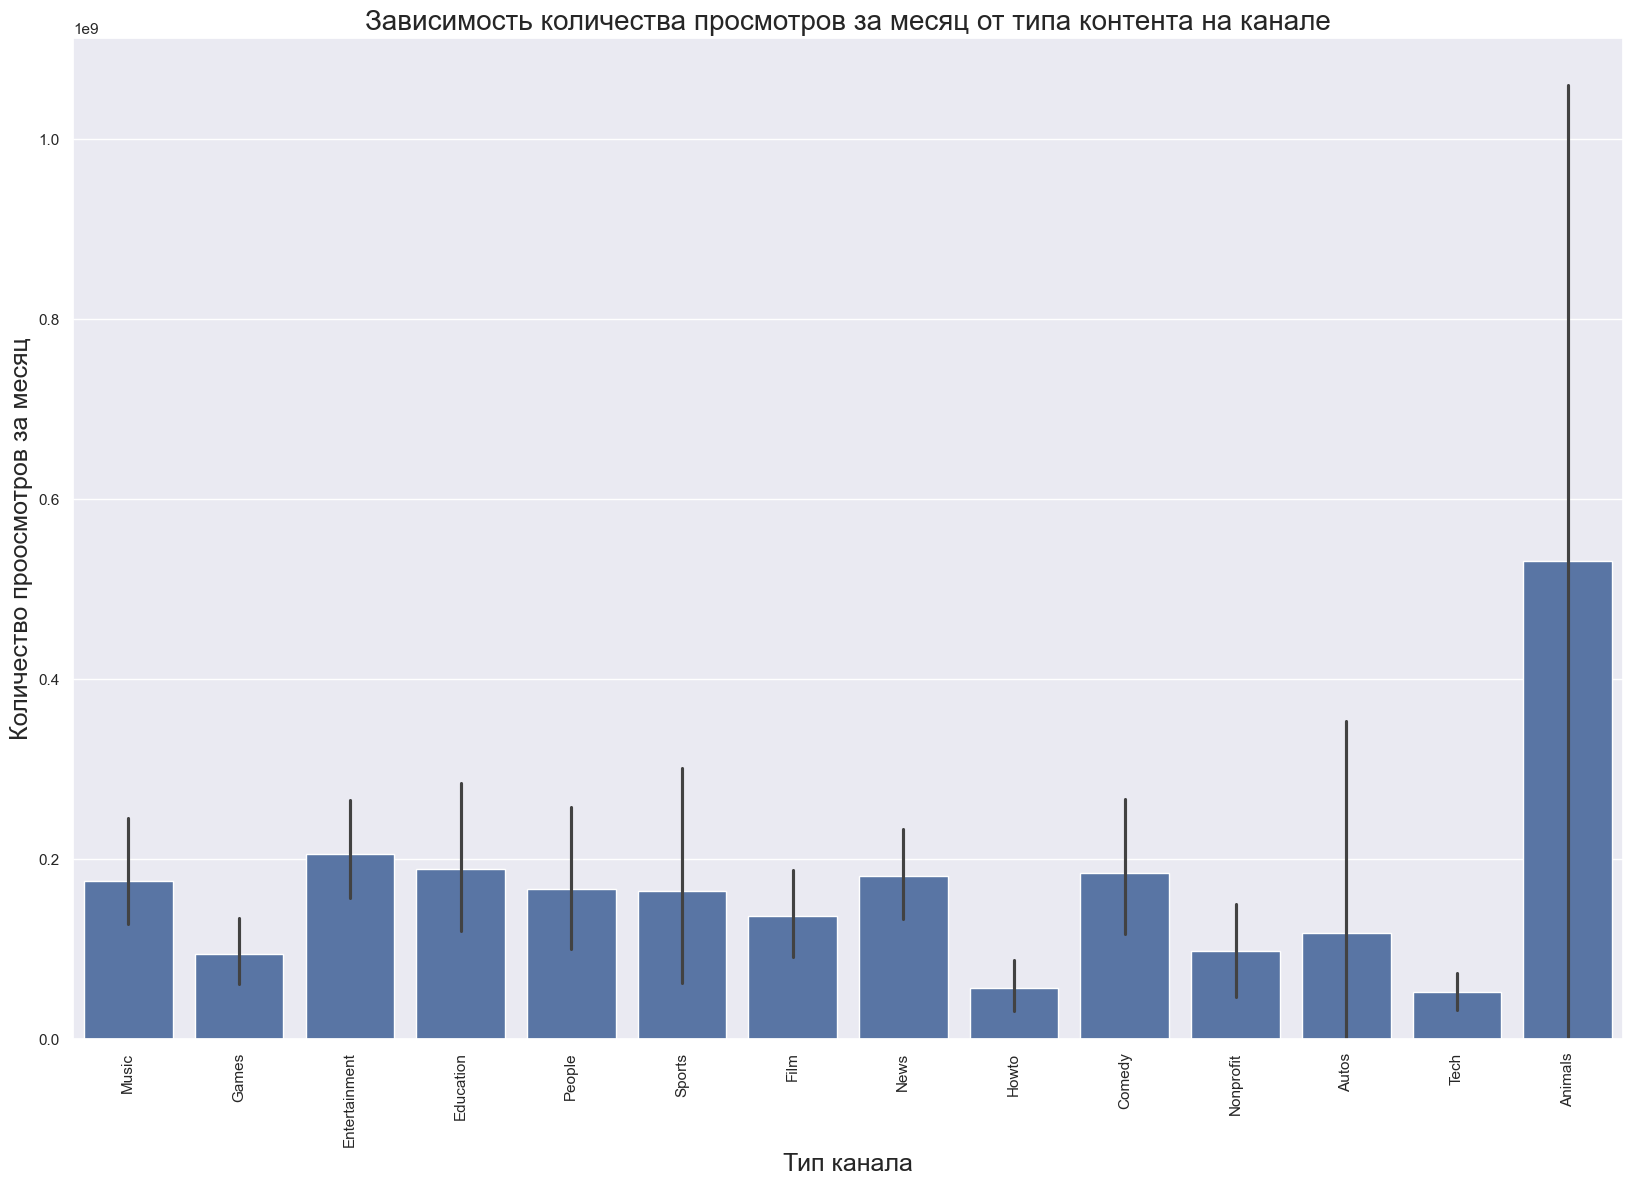

In [179]:
sns.barplot(data=data_youtube, x='channel_type', y='video_views_for_the_last_30_days')
plt.ylabel('Количество проосмотров за месяц',fontsize = 18)
plt.xlabel('Тип канала',fontsize = 18)
plt.title('Зависимость количества просмотров за месяц от типа контента на канале',fontsize = 20)
plt.xticks(rotation=90)
plt.show()

Ответ: нет, больше привлекают пользователей каналы про животных

6) В какой месяц лучше всего создавать канал? Для анализа возьмем 2020 год, в который наблюдается наибольшее количество просмотров на каналах

['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


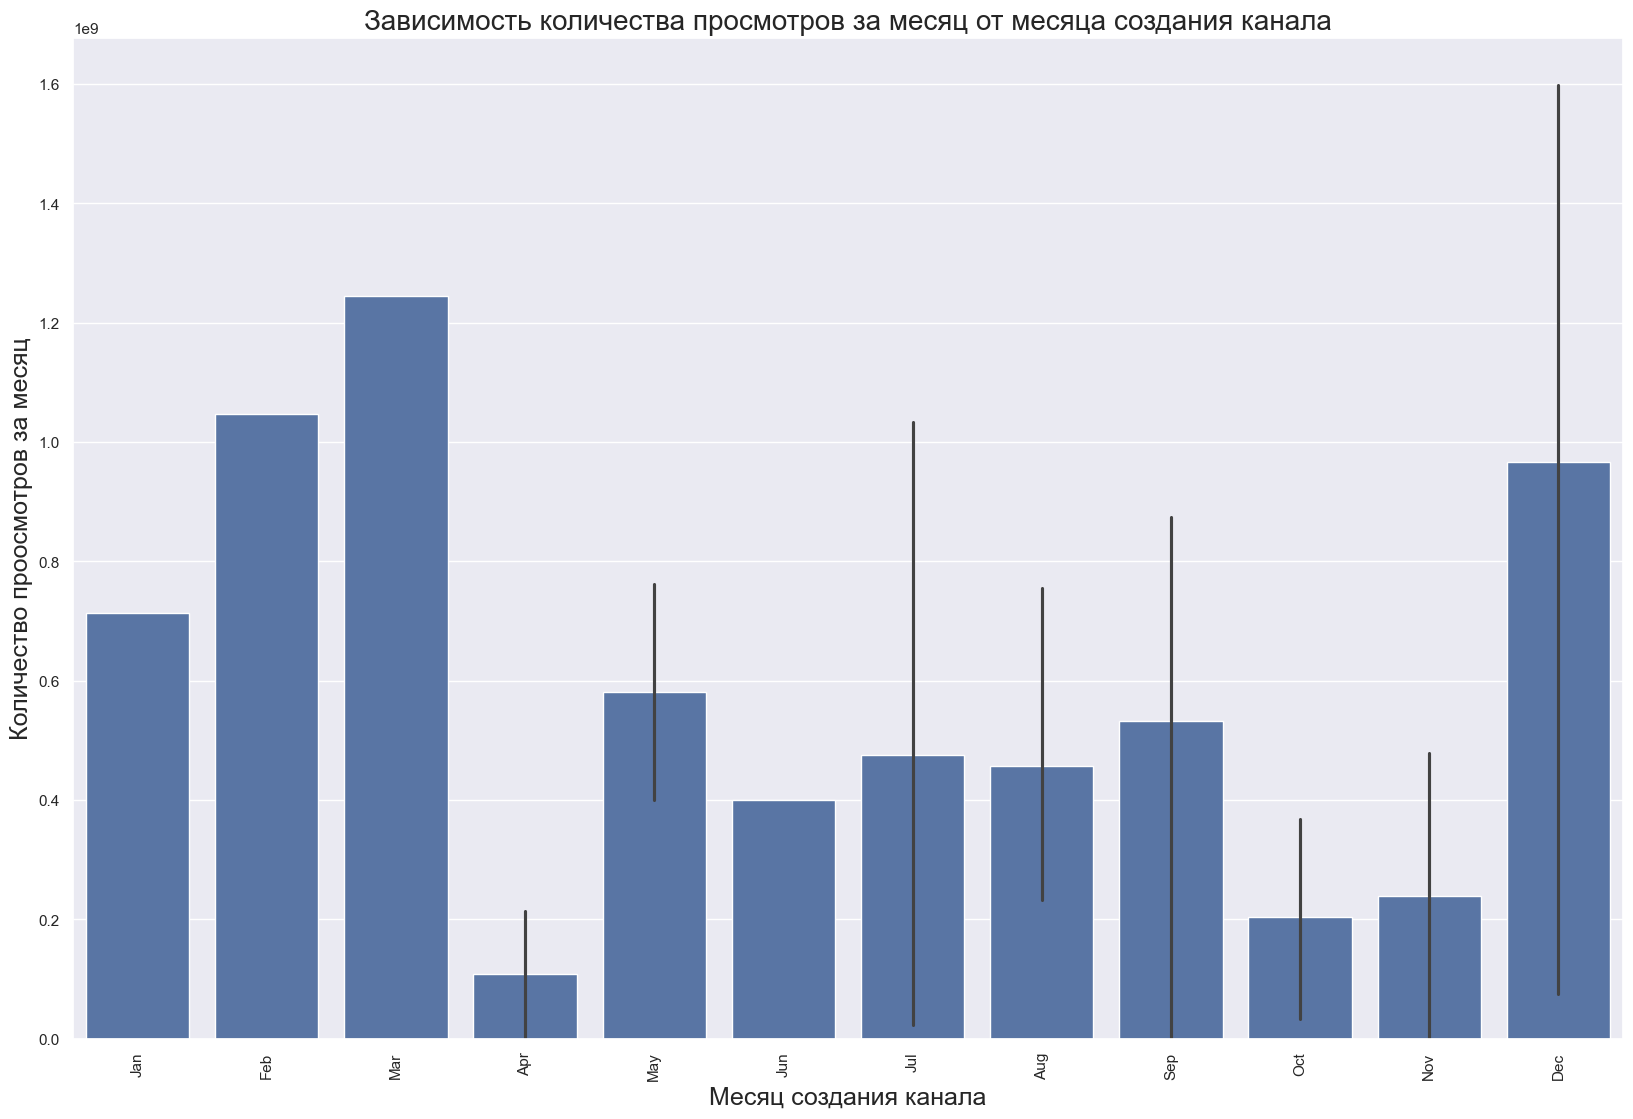

In [180]:
order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(order)
sns.barplot(data=data_youtube[data_youtube['created_year'] == 2020], x='created_month', y='video_views_for_the_last_30_days', order = order)
plt.ylabel('Количество проосмотров за месяц',fontsize = 18)
plt.xlabel('Месяц создания канала',fontsize = 18)
plt.xticks(rotation=90)
plt.title('Зависимость количества просмотров за месяц от месяца создания канала',fontsize = 20)
plt.show()

Ответ: лучше всего создавать канал в марте

Посмотрим матрицу корреляций

<Axes: >

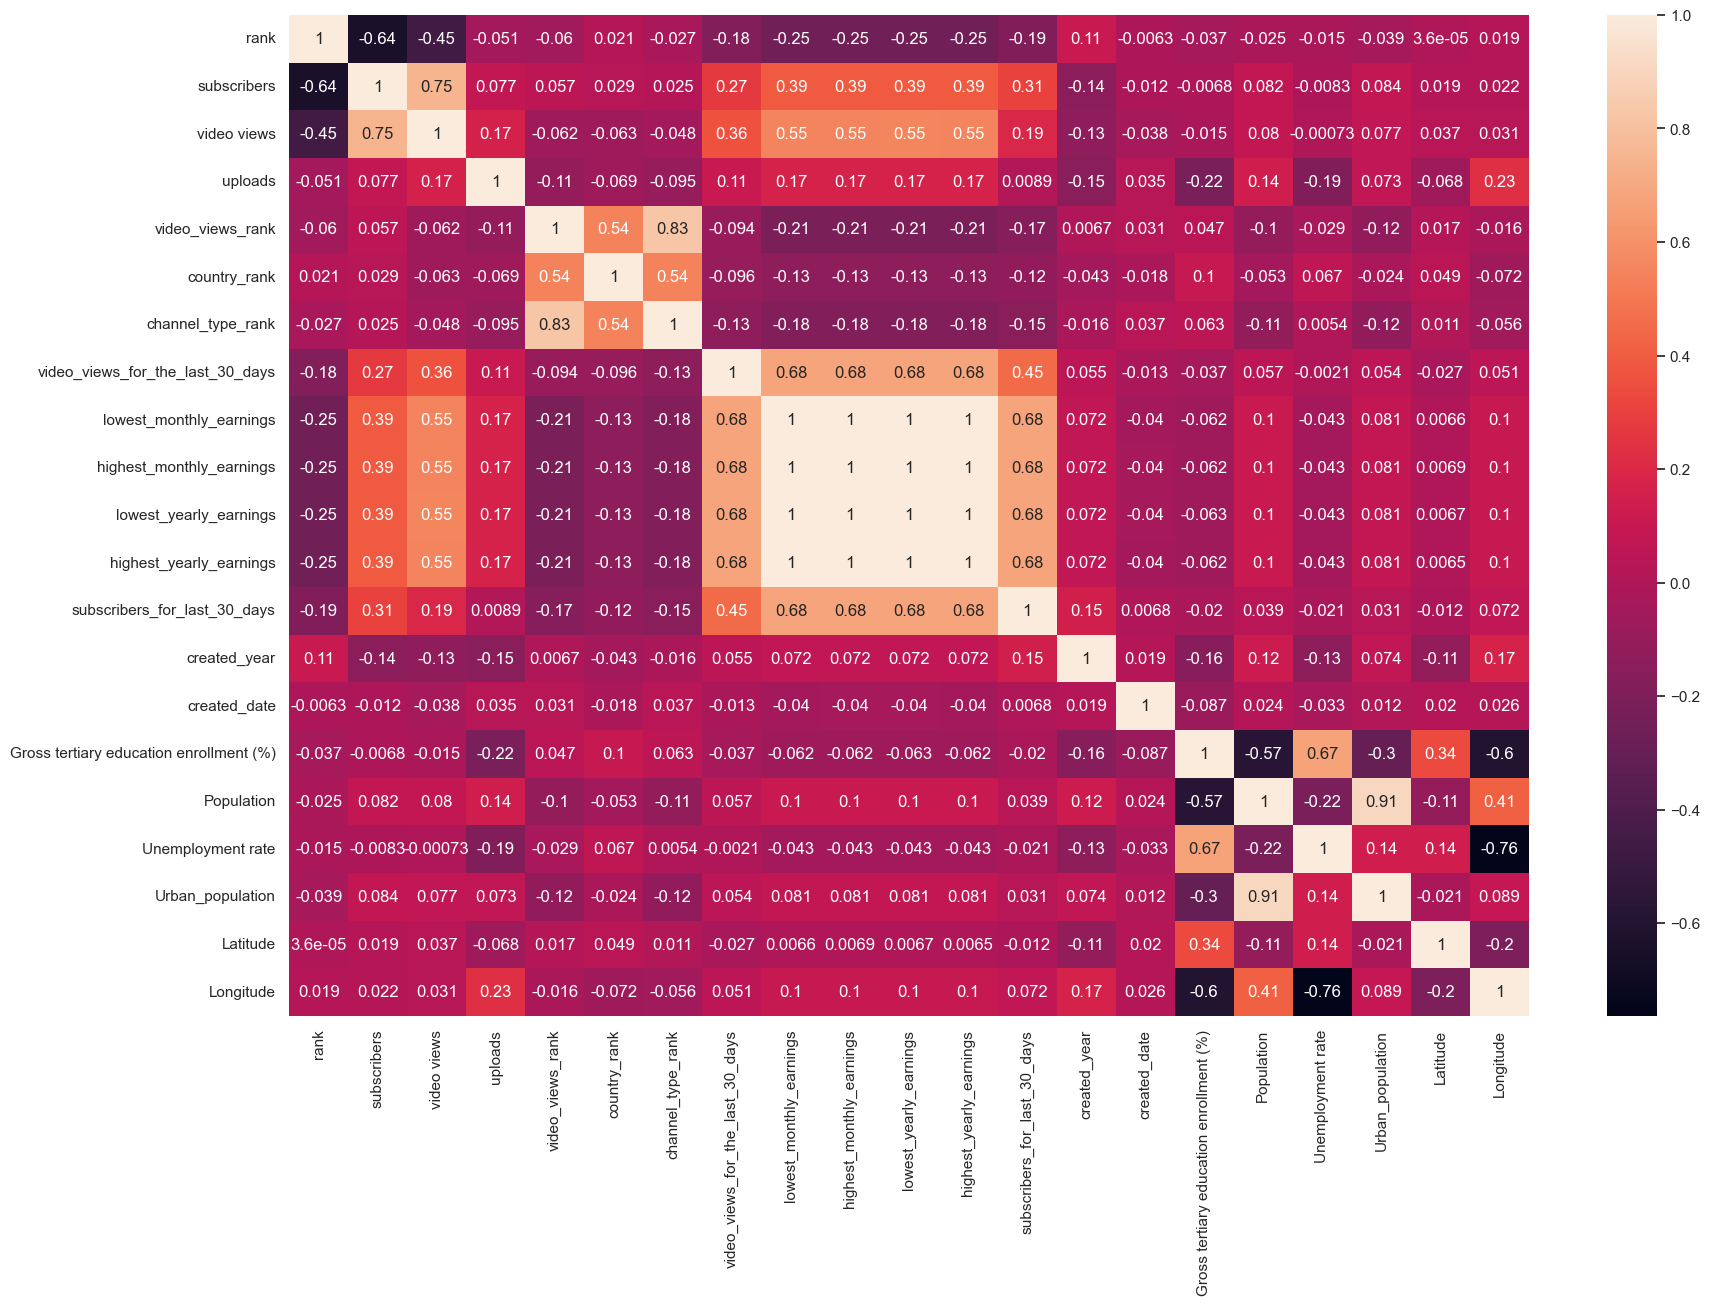

In [160]:
df = data_youtube.drop(['Youtuber', 'Country','category','Title','Abbreviation','channel_type','created_month'], axis=1)
sns.set(rc={'figure.figsize':(20,13)})
sns.heatmap(df.corr(), annot=True)

# Задание 2. Корреляционный анализ

1) Оставьте два коррелирующих столбца: "subscribers" и"video views".
2) Отфильтруйте данные - уберите те строки, где кол-во просмотров равно нулю.
3) Рассчитайте коэффициент корреляции Пирсона.
4) Определите "video views" как признак Х, а "subscribers" - как целевую переменную.
5) Разделите выборку на тестовую и тренировочную.
6) Постройте модель линейной регрессии.
7) Рассчитайте точность модели на тестовой выборке.
8) Как изменится точность, если опустить пункт 2 и не убирать из данных нулевые просмотры?

In [266]:
data_youtube_2 = data_youtube[['subscribers','video views']]
data_youtube_2 = data_youtube_2[data_youtube_2['video views'] != 0]
data_youtube_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 987 entries, 0 to 994
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   subscribers  987 non-null    int64  
 1   video views  987 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 23.1 KB


In [267]:
data_youtube_2.corr()

,subscribers,video views
subscribers,1.000000,0.824262
video views,0.824262,1.000000


<Axes: xlabel='video views', ylabel='subscribers'>

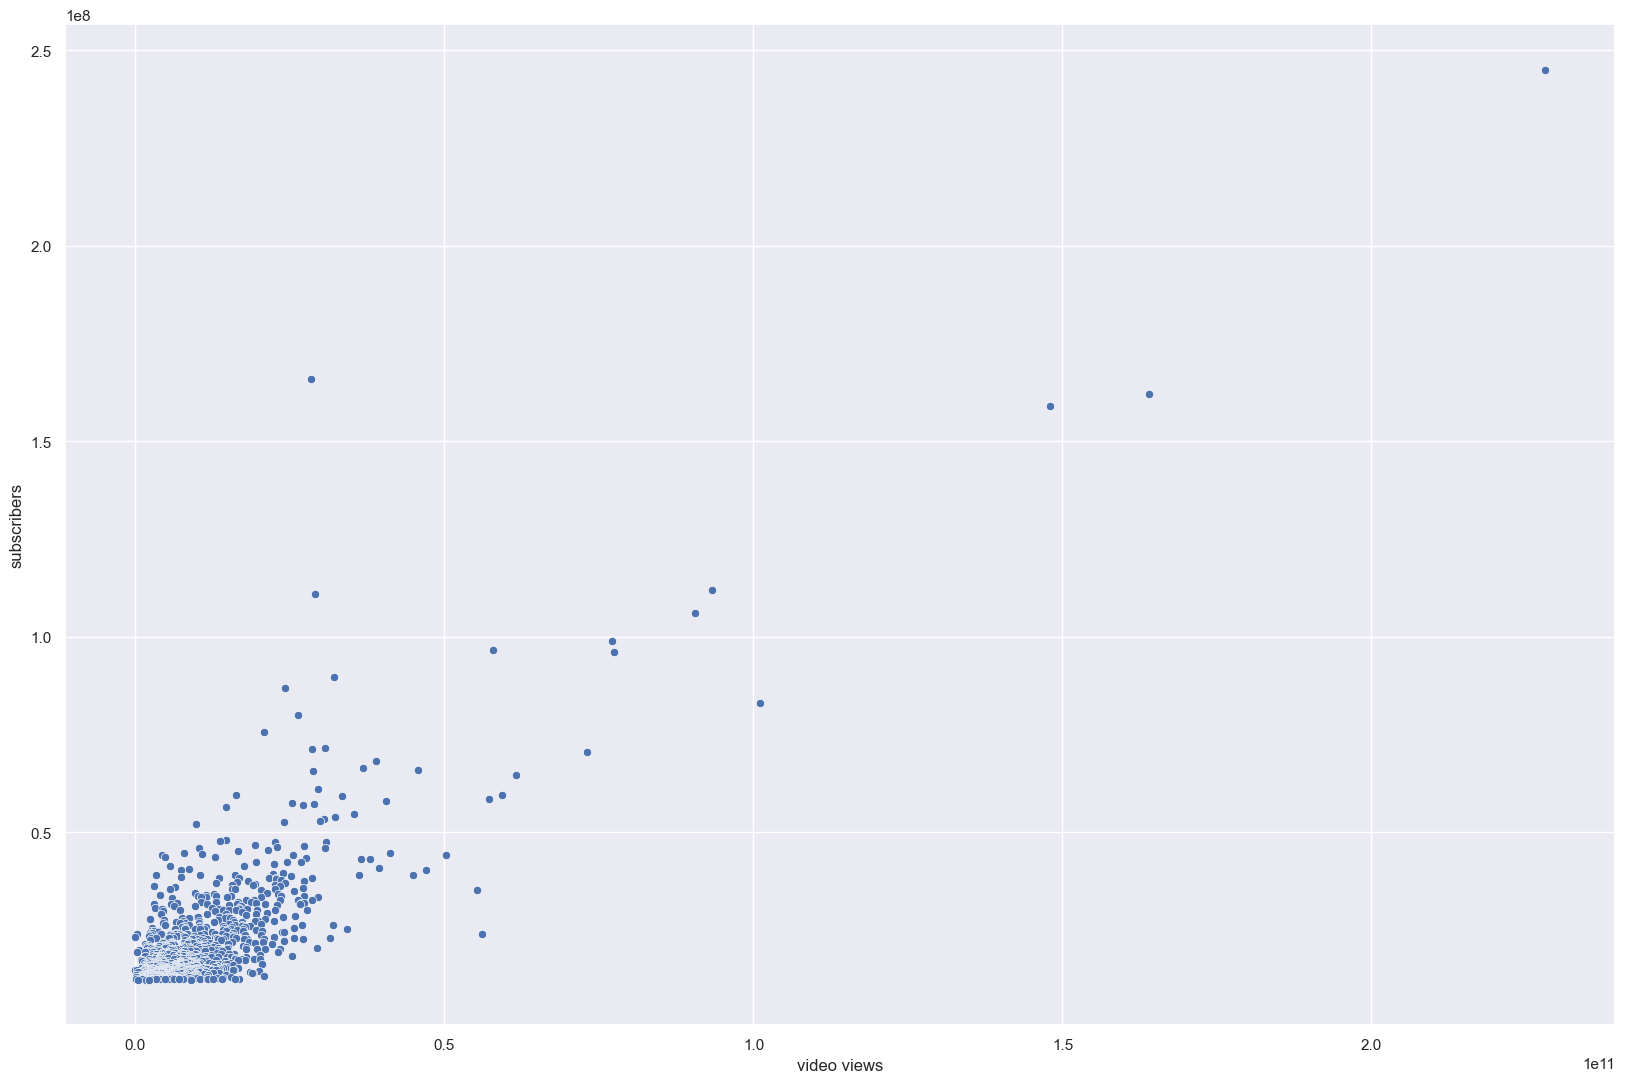

In [268]:
sns.scatterplot(data= data_youtube_2, x ='video views', y = 'subscribers')

In [269]:
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

In [270]:
X = data_youtube_2[['video views']]
Y = data_youtube_2['subscribers']

In [271]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

In [272]:
y_test

315    22300000
144    31700000
506    17600000
862    13300000
92     37600000
         ...   
919    12900000
475    18100000
739    14500000
831    13600000
956    12500000
Name: subscribers, Length: 297, dtype: int64

Построение модели линейной регрессии

In [196]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

Коэффициенты уравнения

In [276]:
model.coef_
model.intercept_
print(f"{model.coef_[0]:.10f}x + {model.intercept_:.2f}")

0.0009380408x + 12749476.63


Тестирование модели

In [277]:
y_pred = model.predict(X_test)
y_pred

array([2.08765026e+07, 2.82055546e+07, 1.48825884e+07, 1.58442763e+07,
       2.98295077e+07, 2.58045877e+07, 1.51037272e+07, 3.67702593e+07,
       3.86100950e+07, 2.17023984e+07, 3.26612166e+07, 3.09740221e+07,
       1.97008622e+07, 3.05358946e+07, 1.44164431e+07, 1.65653129e+07,
       1.70726738e+07, 3.21271212e+07, 5.48683496e+07, 1.46941037e+07,
       2.10814547e+07, 1.42250699e+07, 1.41629131e+07, 2.33384180e+07,
       1.28808234e+07, 1.45041834e+07, 1.43032967e+07, 1.37104692e+07,
       1.45660702e+07, 3.04950385e+07, 3.01178525e+07, 2.20593504e+07,
       1.88789412e+07, 1.55916210e+07, 1.42284228e+07, 1.89245358e+07,
       3.23727302e+07, 1.75279037e+07, 1.38267433e+07, 2.77713034e+07,
       2.17299425e+07, 4.04528508e+07, 3.97998939e+07, 1.92641394e+07,
       4.29024197e+07, 2.45921286e+07, 2.39555160e+07, 2.89859887e+07,
       1.70326835e+07, 1.84232331e+07, 1.59052620e+07, 1.69743005e+07,
       2.60688189e+07, 1.59817720e+07, 1.54774126e+07, 1.89845899e+07,
      

Определение точности модели

In [278]:
model.score(X_test,y_test)

0.6626071385465435

Точность модели невысокая, что говорит о том, что для построения модели, определяющей, как будет расти количество подписчиков от количества просмотров, необходимо использовать более сложный алгоритм, чем линейная регрессия

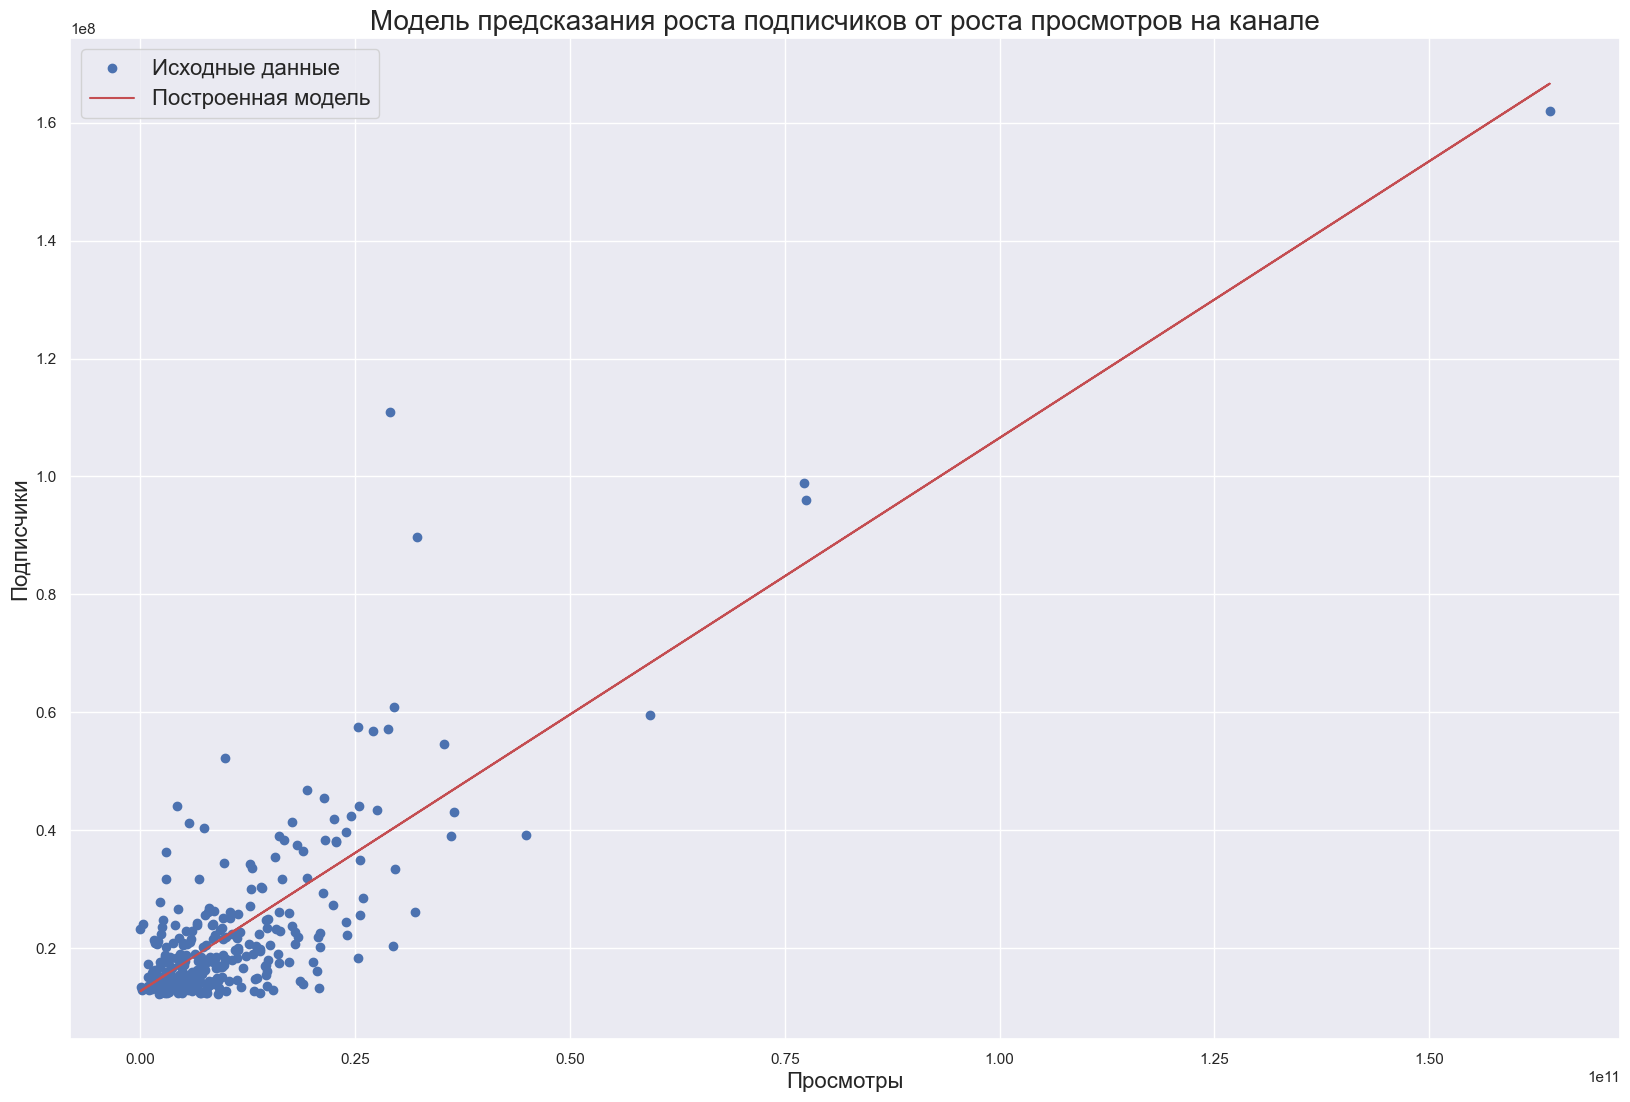

In [279]:
plt.scatter(X_test, y_test, label='Исходные данные')
plt.plot(X_test, y_pred, c='r', label='Построенная модель')
plt.xlabel('Просмотры',fontsize = 16)
plt.ylabel('Подписчики',fontsize = 16)
plt.title('Модель предсказания роста подписчиков от роста просмотров на канале', fontsize = 20)
plt.legend(fontsize = 16)
plt.grid(True)

Построение графика остатков

In [280]:
residuals = y_test - y_pred.flatten()
residuals

315    1.423497e+06
144    3.494445e+06
506    2.717412e+06
862   -2.544276e+06
92     7.770492e+06
           ...     
919   -1.433912e+07
475   -4.690106e+06
739   -1.581294e+06
831   -1.140057e+06
956   -3.195753e+06
Name: subscribers, Length: 297, dtype: float64

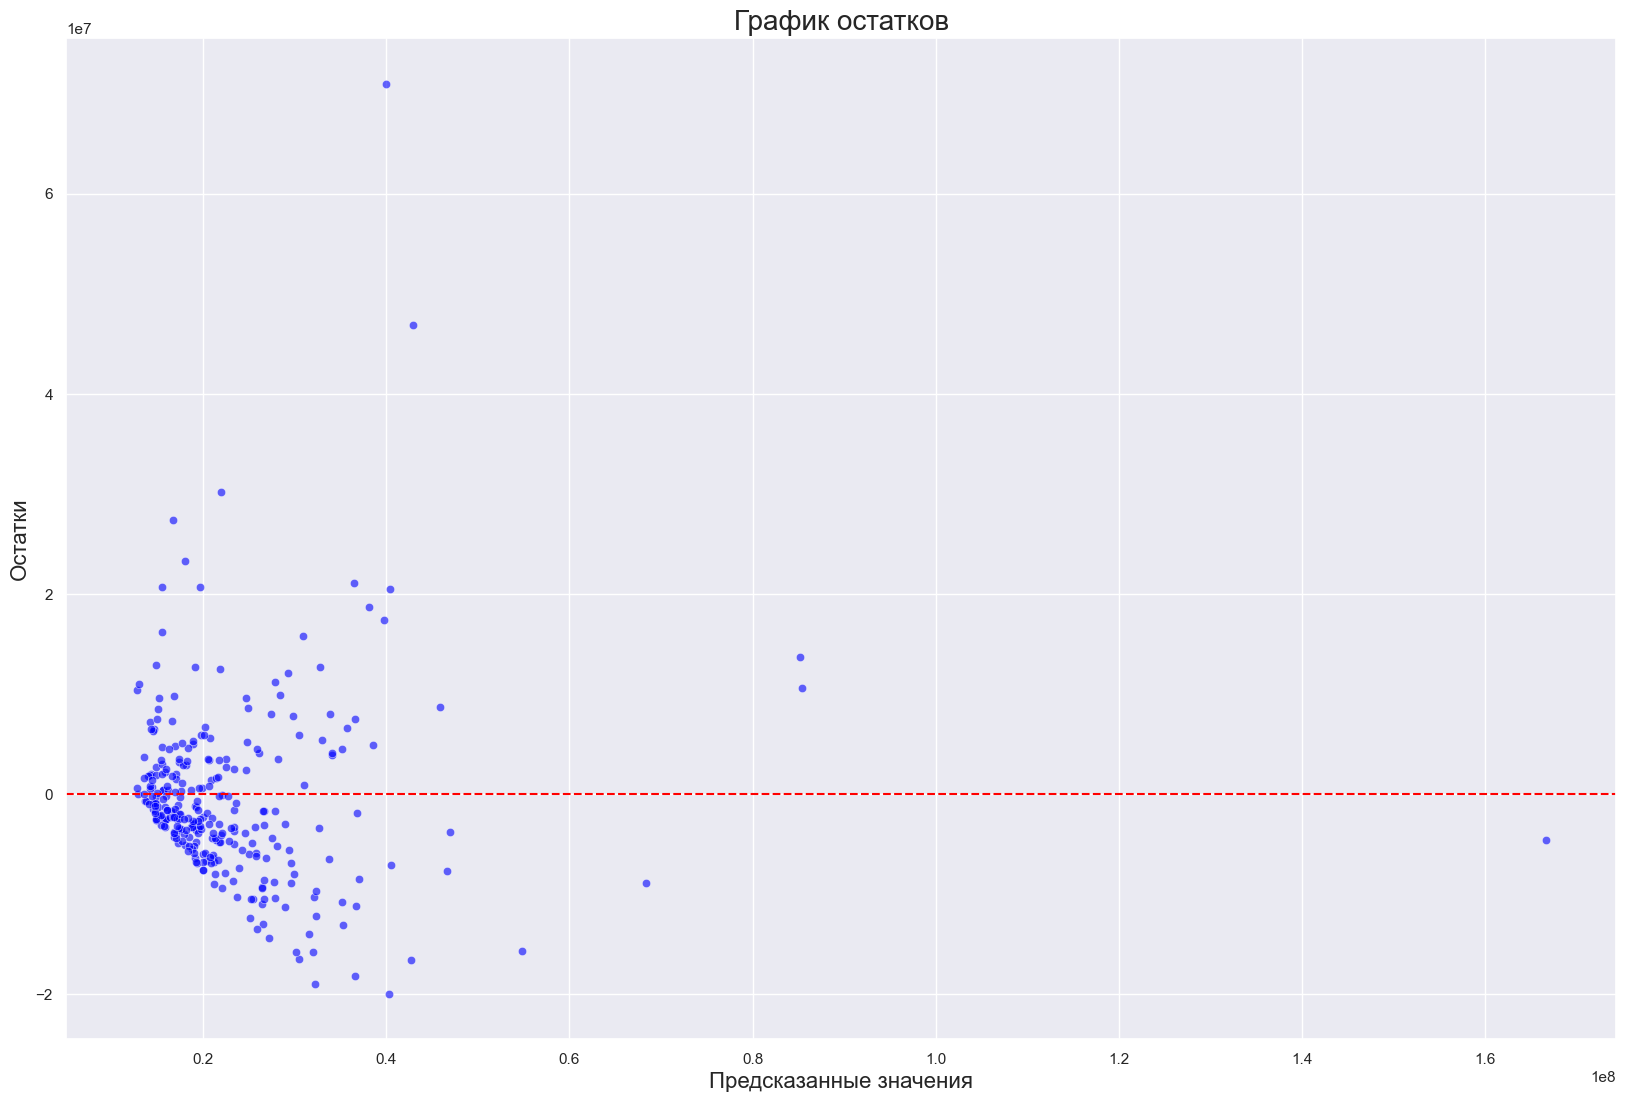

In [281]:

sns.scatterplot(x = y_pred, y = residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения',fontsize = 16)
plt.ylabel('Остатки',fontsize = 16)
plt.title('График остатков',fontsize = 20)
plt.grid(True)
plt.show()

График остатов показывает, что в начале остатки распределены не хаотично, они сконцентрированы в определенной области, что подтверждает вывод о том, что модель работает для этих данных плохо

Как изменится точность, если опустить пункт 2 и не убирать из данных нулевые просмотры? -  точность модели значительно уменьшится - до 37 процентов

# Задание 3. Классификация
1) Определите две самые популярные категории канала и отфильтруйте по ним набор данных.
2) В качестве признаков используйте следующие столбцы: [‘video views’, ‘subscribers’, ‘uploads’]
3) Снова отфильтруйте данные - уберите те строки, где кол-во просмотров равно нулю.
4) Для целевой переменной используйте столбец'category'. Значения по нему закодируйте с помощью LabelEncoder.
5) Разделите выборку на тестовую и тренировочную, укажите random_state=13.`
6) Постройте модель логистической регрессии.
7) Рассчитайте точность модели на тестовой выборке.
Изменится ли точность модели, если в качестве признаков выбрать другие столбцы?

In [282]:
data = data_youtube[['category','video views', 'subscribers', 'uploads']]
# row_max = data.loc[[data['video views'].idxmax()]]
row_max = data.nlargest(2,['video views','subscribers', 'uploads'])
row_max
data = data[(data['category'] == 'Music') | (data['category'] == 'Education') & (data['video views'] != 0)]
data

,category,video views,subscribers,uploads
0,Music,2.280000e+11,245000000,20082
3,Education,1.640000e+11,162000000,966
10,Music,5.785629e+10,96700000,8548
17,Music,2.082699e+10,75600000,2281
19,Music,3.060812e+10,71600000,249
...,...,...,...,...
982,Music,1.260749e+10,12400000,4422
985,Education,3.392023e+09,12400000,0
987,Music,6.202090e+09,12400000,205
988,Education,4.779140e+09,12400000,1340


In [283]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(data['category'].values)
data_cat = le.transform(data['category'].values)
data_cat

array([1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 1])

Разделение выборки

In [285]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data[['video views', 'subscribers', 'uploads']], data_cat, test_size=0.2, random_state=13)


Нормализация данных

In [314]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[['video views', 'subscribers', 'uploads']])
X_test_scaled = scaler.transform(X_test[['video views', 'subscribers', 'uploads']])

In [319]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled,y_train)

LogisticRegression()

Тестирование модели

In [322]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1])

In [323]:
y_test

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1])

Определим вероятность принадлежности к конкретному классу

In [324]:
lr.predict_proba(X_test_scaled)

array([[0.17001395, 0.82998605],
       [0.17558246, 0.82441754],
       [0.16673291, 0.83326709],
       [0.18284394, 0.81715606],
       [0.16923747, 0.83076253],
       [0.17721075, 0.82278925],
       [0.1643614 , 0.8356386 ],
       [0.16308281, 0.83691719],
       [0.16940607, 0.83059393],
       [0.16469669, 0.83530331],
       [0.19675078, 0.80324922],
       [0.17031787, 0.82968213],
       [0.16503566, 0.83496434],
       [0.17568095, 0.82431905],
       [0.17303783, 0.82696217],
       [0.16155059, 0.83844941],
       [0.16368362, 0.83631638],
       [0.16716655, 0.83283345],
       [0.17296581, 0.82703419],
       [0.1652634 , 0.8347366 ],
       [0.1679352 , 0.8320648 ],
       [0.17214491, 0.82785509],
       [0.17561835, 0.82438165],
       [0.16838599, 0.83161401],
       [0.16639212, 0.83360788],
       [0.17272373, 0.82727627],
       [0.17911874, 0.82088126],
       [0.16757926, 0.83242074],
       [0.16937197, 0.83062803],
       [0.16724716, 0.83275284],
       [0.

Коэффициенты логистической регрессии

In [325]:
lr.coef_

array([[ 0.07538711, -0.14166462,  0.0372914 ]])

Расчет точности модели

In [328]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, lr.predict(X_test_scaled))

0.78

Точность модели достаточно высокая

Визуализация

In [329]:
import numpy as np

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


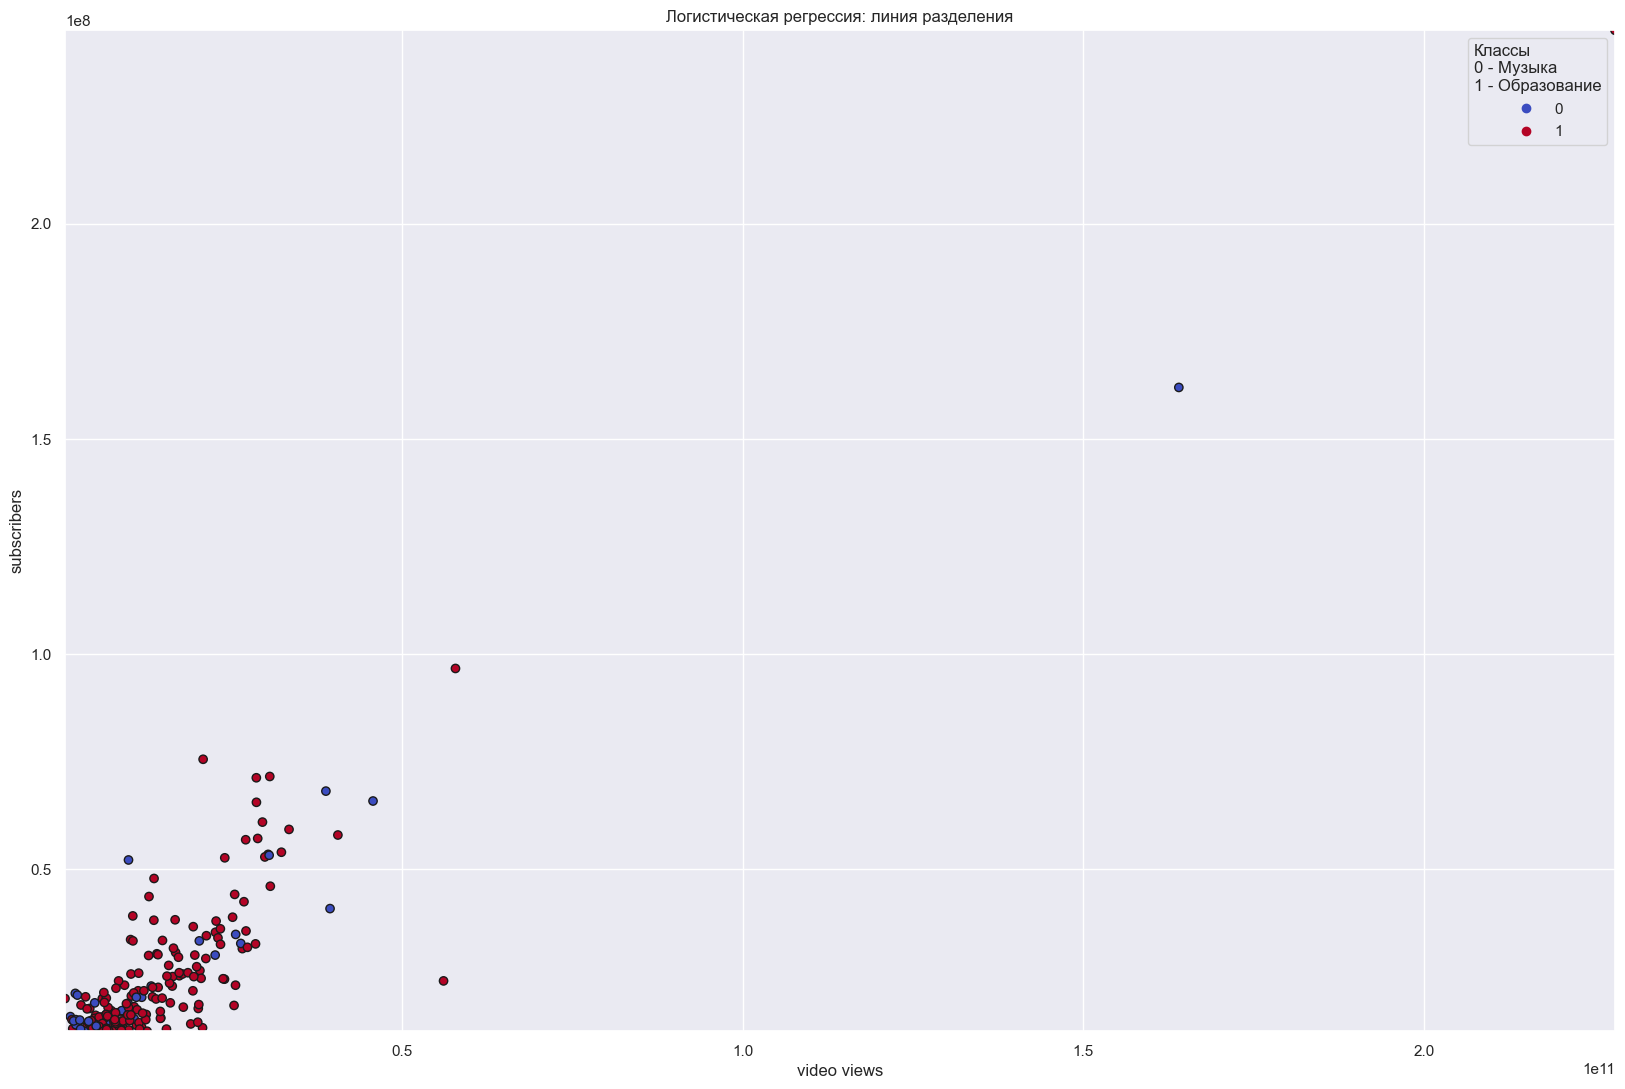

In [ ]:
scatter = plt.scatter(X_train['video views'], X_train['subscribers'], c=y_train)


x_min, x_max = X_train['video views'].min(), X_train['video views'].max()
y_min, y_max = X_train['subscribers'].min(), X_train['subscribers'].max()

nx, ny = 200, 100
xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx), np.linspace(y_min, y_max, ny))

fixed_uploads = X_train['uploads'].mean()

grid = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, fixed_uploads)]
grid_scaled = scaler.transform(grid)

Z = lr.predict_proba(grid_scaled)[:, 1].reshape(xx.shape)

# plt.pcolormesh(xx, yy, Z, cmap='coolwarm')

plt.contour(xx, yy, Z, levels = [0.5], linewidths=2, colors='black')
plt.legend(*scatter.legend_elements(), title="Классы\n0 - Музыка\n1 - Образование")

plt.show()

In [339]:
print(Z.min(), Z.max())

0.5502847162076621 0.91818985334129


Модель сильно смещена в сторону класса 1. Возможно, данные неразделимы на 2 класса по выбранным признакам и стоит попробовать другие признаки

In [340]:
print(np.bincount(y_train))

[ 34 163]


Данные сильно несбалансированы, 34 раза встречается класс, характеризующий категорию "музыка" и 163 раза - "образование"

Попробуем посмотреть модель для других признаков

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


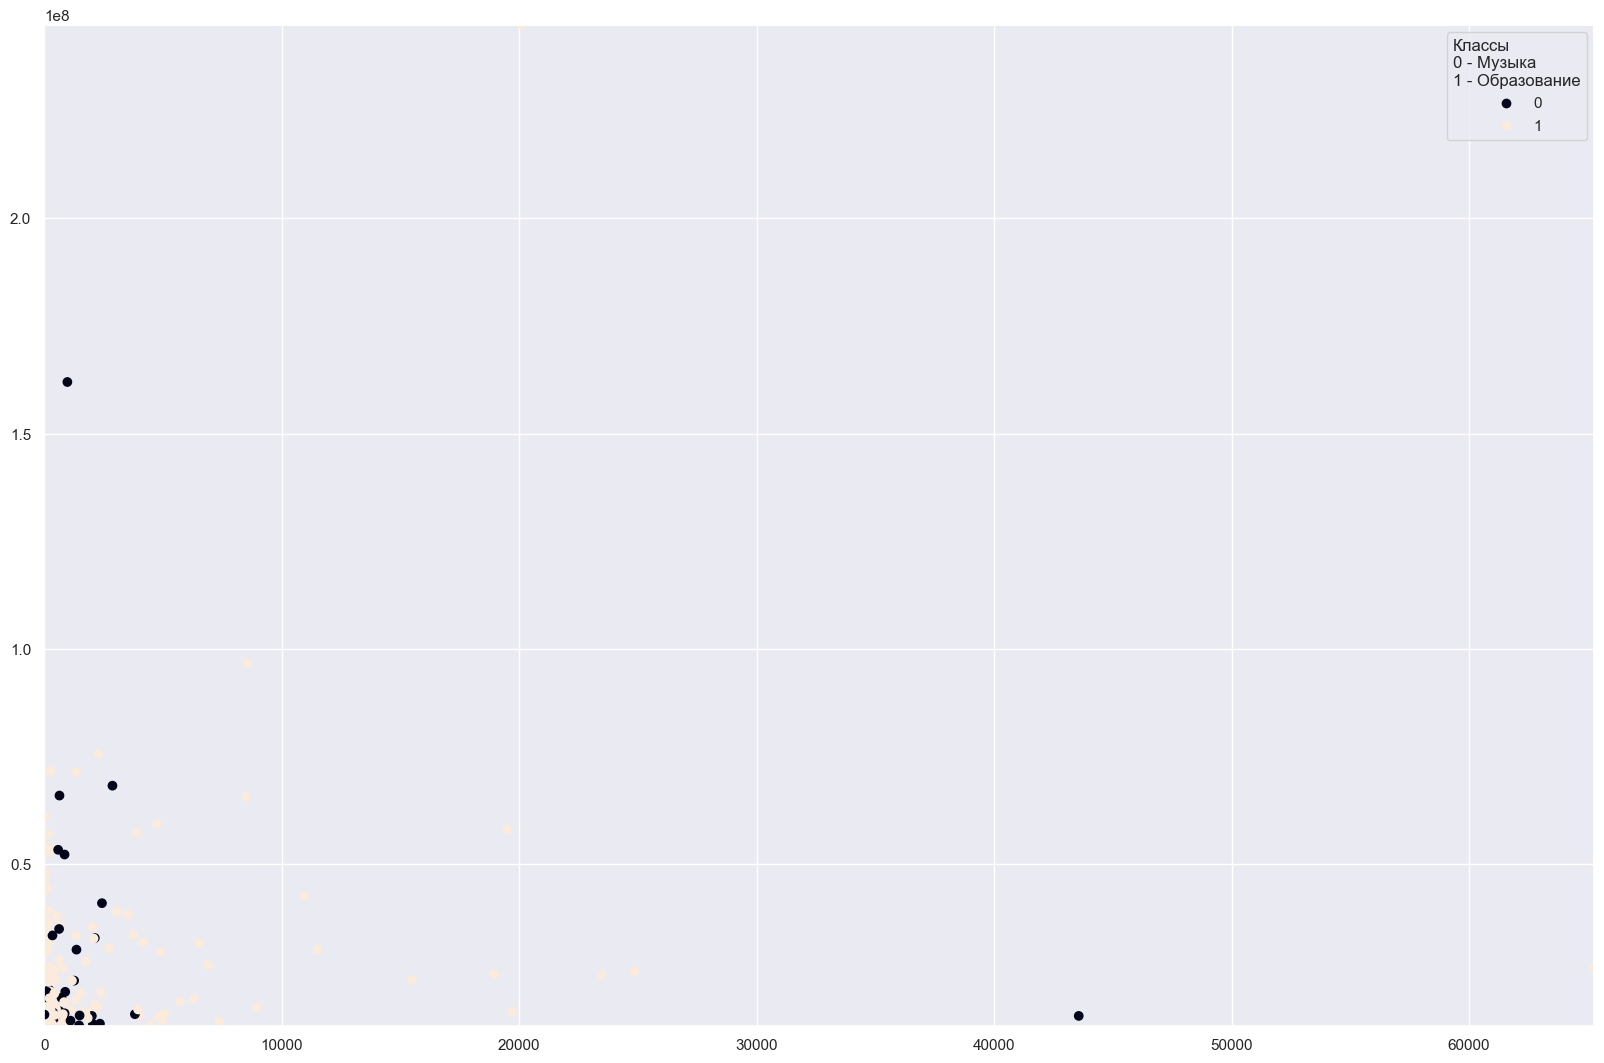

In [341]:
scatter = plt.scatter(X_train['uploads'], X_train['subscribers'], c=y_train)


x_min, x_max = X_train['uploads'].min(), X_train['uploads'].max()
y_min, y_max = X_train['subscribers'].min(), X_train['subscribers'].max()

nx, ny = 200, 100
xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx), np.linspace(y_min, y_max, ny))

fixed_uploads = X_train['video views'].mean()

grid = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, fixed_uploads)]
grid_scaled = scaler.transform(grid)

Z = lr.predict_proba(grid_scaled)[:, 1].reshape(xx.shape)

# plt.pcolormesh(xx, yy, Z, cmap='coolwarm')

plt.contour(xx, yy, Z, levels = [0.5], linewidths=2, colors='black')
plt.legend(*scatter.legend_elements(), title="Классы\n0 - Музыка\n1 - Образование")

plt.show()

In [342]:
print(Z.min(), Z.max())

1.0 1.0


Еще хуже распределение вероятностей

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


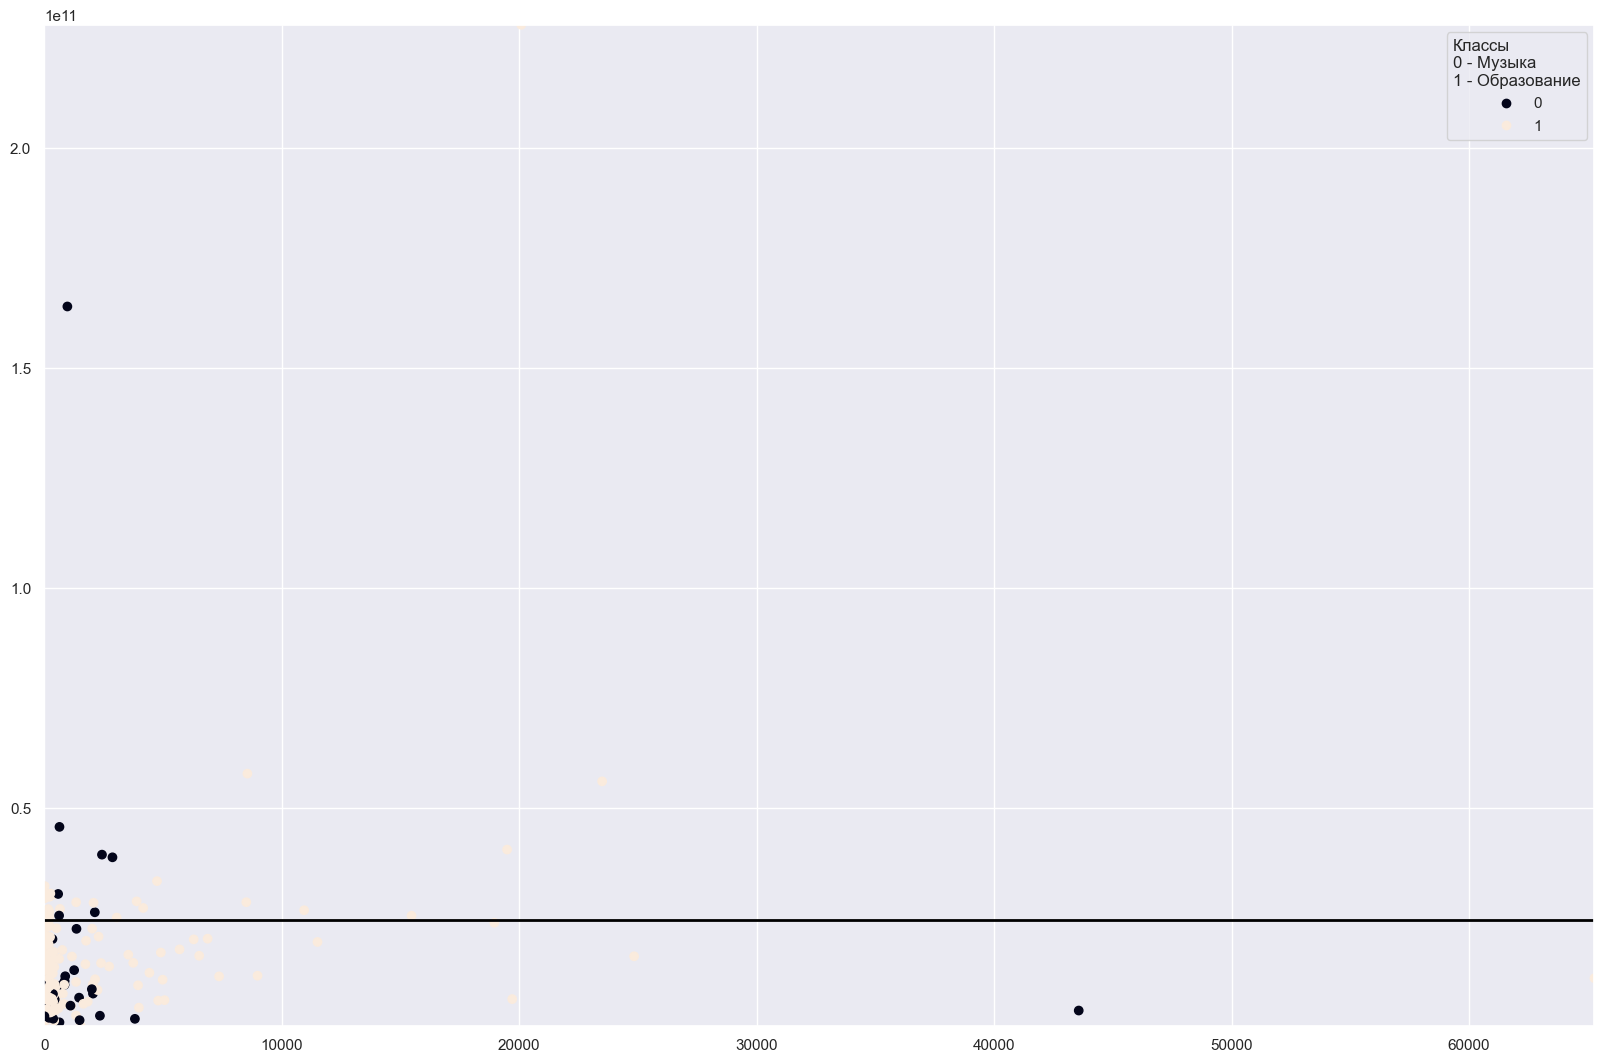

In [344]:
scatter = plt.scatter(X_train['uploads'], X_train['video views'], c=y_train)


x_min, x_max = X_train['uploads'].min(), X_train['uploads'].max()
y_min, y_max = X_train['video views'].min(), X_train['video views'].max()

nx, ny = 200, 100
xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx), np.linspace(y_min, y_max, ny))

fixed_uploads = X_train['subscribers'].mean()

grid = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, fixed_uploads)]
grid_scaled = scaler.transform(grid)

Z = lr.predict_proba(grid_scaled)[:, 1].reshape(xx.shape)

# plt.pcolormesh(xx, yy, Z, cmap='coolwarm')

plt.contour(xx, yy, Z, levels = [0.5], linewidths=2, colors='black')
plt.legend(*scatter.legend_elements(), title="Классы\n0 - Музыка\n1 - Образование")

plt.show()

In [345]:
print(Z.min(), Z.max())

0.0 1.0


Попробуем сместить фиксированное среднее значение и посмотреть, меняется ли диапазон вероятностей

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


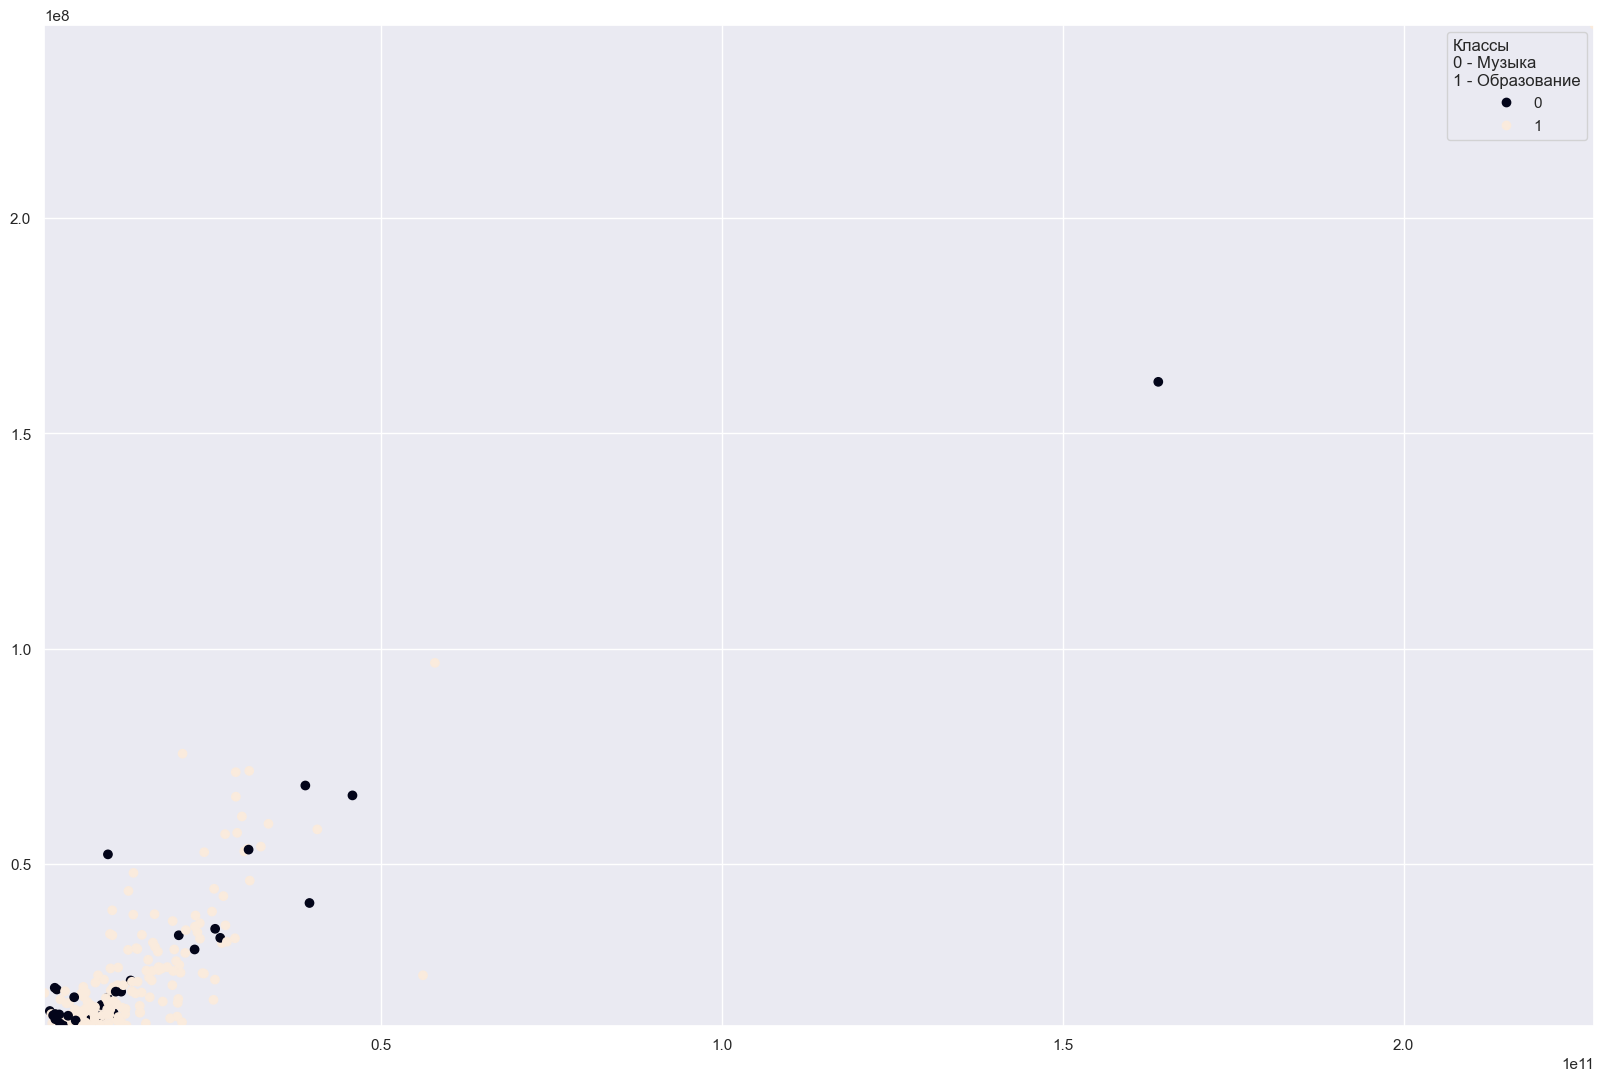

In [369]:
scatter = plt.scatter(X_train['video views'], X_train['subscribers'], c=y_train)


x_min, x_max = X_train['video views'].min(), X_train['video views'].max()
y_min, y_max = X_train['subscribers'].min(), X_train['subscribers'].max()

nx, ny = 200, 100
xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx), np.linspace(y_min, y_max, ny))

fixed_uploads = X_train['uploads'].mean()

grid = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, fixed_uploads)]
grid_scaled = scaler.transform(grid)

Z = lr.predict_proba(grid_scaled)[:, 1].reshape(xx.shape)

# plt.pcolormesh(xx, yy, Z, cmap='coolwarm')

plt.contour(xx, yy, Z, levels = [0.5], linewidths=2, colors='black')
plt.legend(*scatter.legend_elements(), title="Классы\n0 - Музыка\n1 - Образование")

plt.show()

In [355]:
print(Z.min(), Z.max())

0.5502847162076621 0.91818985334129


Можно сделать вывод, что модель сильно сдвинута к классу 1, так как имеет сильно несбалансированные данные, поэтому на визуализации не видно прямой, разделяющей два класса